In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-06-17T05:23:10.458549+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1029-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot: 1.4.2
numpy  : 2.1.2
pandas : 2.2.3
seaborn: 0.13.2
polars : 1.29.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-vanilla-big-1.3x-summary"
teeplot_subdir


'2025-05-19-compscreen-vanilla-big-1.3x-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/mkjy5/download",
    # "multistrain": "https://osf.io/ywmpt/download",
    # "vanilla": "https://osf.io/r8skg/download",
    # "vanilla-big": "https://osf.io/j4795/download",
    "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            "defmut_norm_ot_bin:month-num_leaves",
            # "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            # "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            "defmut_norm_ot_bin:month-clade_duration",
            # "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            # "defmut_norm_match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


--2025-06-17 05:23:10--  https://osf.io/cnp5z/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b?action=download&direct&version=1 [following]
--2025-06-17 05:23:10--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682caa9fbb3f815770b06c6b?action=download&direct&version=1
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 801307036 (764M) [application/octet-stream]
Saving to: ‘/tmp/2025-05-19-compscreen-vanilla-big-1.3x-summary.pqt’

/tmp/2025-05-19-com 100%[===================>] 764.19M  3.82MB/s    in 3m 4s   

2025-06-17 05:26:15 (4.16 MB/s) - ‘/tmp/2025-05-19-compscreen-vanilla-big-1.3x-summary.pqt’ saved [801307036/801307036]



done!


100%|██████████| 20/20 [01:52<00:00,  5.62s/it]


In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na,n_grp
0,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,b2138f47-760a-870b-871e-9c8cd9168072,defmut_norm_all-num_leaves,all,6101,3516,6101,10000,0.4972,5.054307e-01,NaN,NaN,NaN,0,6101
1,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,b2138f47-760a-870b-871e-9c8cd9168072,defmut_norm_all-num_leaves,False,4441,2511,6101,10000,0.8632,9.308779e-01,1.826870e-02,3801021.0,0.031196,0,4441
2,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,b2138f47-760a-870b-871e-9c8cd9168072,defmut_norm_all-num_leaves,True,1660,1005,6101,10000,0.0385,8.589034e-03,9.817321e-01,3571039.0,-0.031196,0,1660
3,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,b2138f47-760a-870b-871e-9c8cd9168072,defmut_norm_ot_bin:month-num_leaves,all,6101,3525,6101,10000,0.5037,5.054383e-01,NaN,NaN,NaN,0,6101
4,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,b2138f47-760a-870b-871e-9c8cd9168072,defmut_norm_ot_bin:month-num_leaves,False,4441,2519,6101,10000,0.6126,9.249407e-01,9.996569e-01,3478297.0,-0.056357,0,4441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,defmut_norm_all-clade_duration,False,4481,2607,5808,10000,0.9991,9.982946e-01,3.106382e-12,3299011.0,0.109604,0,4481
236,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,defmut_norm_all-clade_duration,True,1327,896,5808,10000,0.0000,3.281069e-08,1.000000e+00,2647276.0,-0.109604,0,1327
237,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,defmut_norm_ot_bin:month-clade_duration,all,5808,3513,5808,10000,0.5066,5.122043e-01,NaN,NaN,NaN,0,5808
238,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,c8b6eec3-f562-8a2a-a720-f23d4acf1d94,defmut_norm_ot_bin:month-clade_duration,False,4481,2616,5808,10000,0.9915,9.981660e-01,3.465165e-01,2994308.0,0.007119,0,4481


In [9]:
results_df[results_df["label"] == True].groupby(  # noqa: E712
    ["trt_name", "trt_n_downsample", "trt_hsurf_bits", "y"]
).agg(
    {"n_grp": ["mean", "std"]},
)


n_grp  \
                                                                                             mean   
trt_name          trt_n_downsample trt_hsurf_bits y                                                 
Sben1.3x/Gdel1.3x 200000           0              defmut_norm_all-clade_duration            248.8   
                                                  defmut_norm_all-num_leaves                248.8   
                                                  defmut_norm_ot_bin:month-clade_duration   248.8   
                                                  defmut_norm_ot_bin:month-num_leaves       248.8   
                  2000000          0              defmut_norm_all-clade_duration           1292.0   
                                                  defmut_norm_all-num_leaves               1292.0   
                                                  defmut_norm_ot_bin:month-clade_duration  1292.0   
                                                  defmut_norm_ot_bin:month-num_leaves      1292.0   
Sben1.3x/Gneu     200000           0              defmut_norm_all-clade_duration            484.0   
                                                  defmut_norm_all-num_leaves                484.0   
                                                  defmut_norm_ot_bin:month-clade_duration   484.0   
                                                  defmut_norm_ot_bin:month-num_leaves       484.0   
                  2000000          0              defmut_norm_all-clade_duration           1758.8   
                                                  defmut_norm_all-num_leaves               1758.8   
                                                  defmut_norm_ot_bin:month-clade_duration  1758.8   
                                                  defmut_norm_ot_bin:month-num_leaves      1758.8   

                                                                                                      
                                                                                                 std  
trt_name          trt_n_downsample trt_hsurf_bits y                                                   
Sben1.3x/Gdel1.3x 200000           0              defmut_norm_all-clade_duration           15.801899  
                                                  defmut_norm_all-num_leaves               15.801899  
                                                  defmut_norm_ot_bin:month-clade_duration  15.801899  
                                                  defmut_norm_ot_bin:month-num_leaves      15.801899  
                  2000000          0              defmut_norm_all-clade_duration           23.653752  
                                                  defmut_norm_all-num_leaves               23.653752  
                                                  defmut_norm_ot_bin:month-clade_duration  23.653752  
                                                  defmut_norm_ot_bin:month-num_leaves      23.653752  
Sben1.3x/Gneu     200000           0              defmut_norm_all-clade_duration           36.013886  
                                                  defmut_norm_all-num_leaves               36.013886  
                                                  defmut_norm_ot_bin:month-clade_duration  36.013886  
                                                  defmut_norm_ot_bin:month-num_leaves      36.013886  
                  2000000          0              defmut_norm_all-clade_duration           59.187837  
                                                  defmut_norm_all-num_leaves               59.187837  
                                                  defmut_norm_ot_bin:month-clade_duration  59.187837  
                                                  defmut_norm_ot_bin:month-num_leaves      59.187837

In [10]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_match:")
results_df["y"] = results_df["y"].str.replace("-", "\n")
results_df["y"] = results_df["y"].str.replace("_", " ")

results_df["label"] = results_df["label"].astype(str)
results_df["label"] = results_df["label"].str.replace("False", "bkgnd")
results_df["label"] = results_df["label"].str.replace("True", "focal")

results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-boot+ext=.png


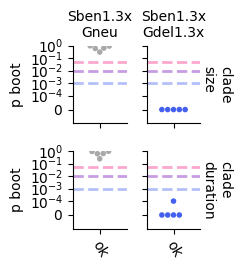

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-binom+ext=.png


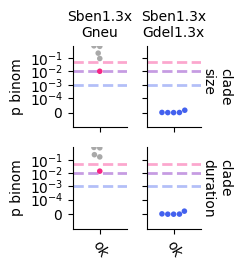

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=y+viz=catplot+x=smallsamp+y=p-mw+ext=.png


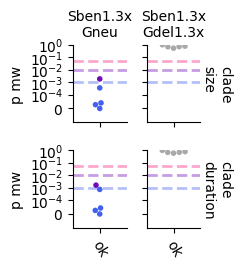

In [11]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    data["smallsamp"] = data["n_grp"] < 30
    data["smallsamp"] = data["smallsamp"].map({True: "<30", False: "ok"})
    data["y_"] = (
        data["y"]
        .str.replace("month\n", "")
        .str.replace("num leaves", "clade\nsize")
        .str.replace("clade duration", "clade\nduration")
    )
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data[
            data["y"].str.startswith("month").values
            & (data["label"] == "focal")
        ],
        y=y,
        col="trt_name_",
        row="y_",
        hue="sig",
        x="smallsamp",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.4,
        aspect=0.9,
        size=4,
        palette=gentle_palette,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:

        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


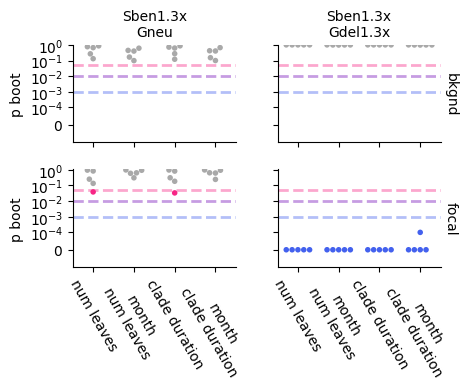

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


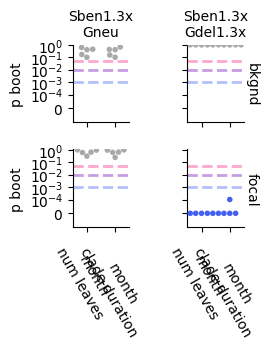

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


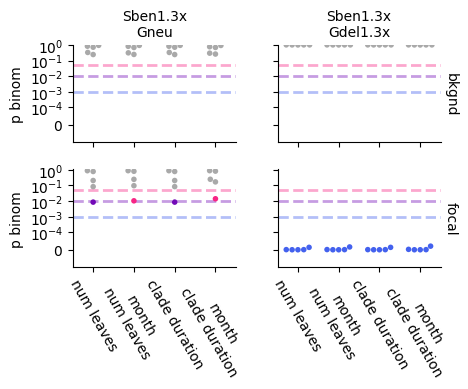

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


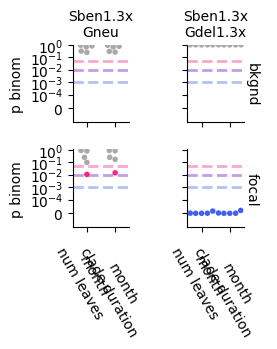

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


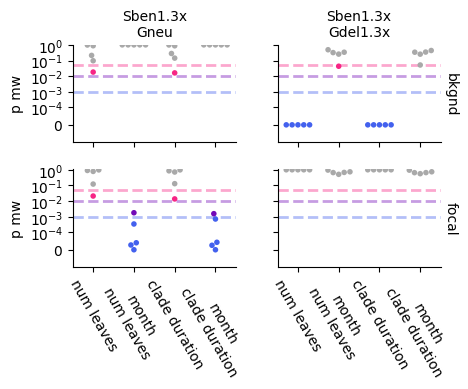

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


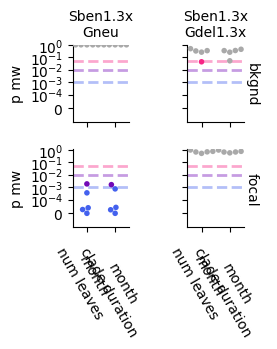

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


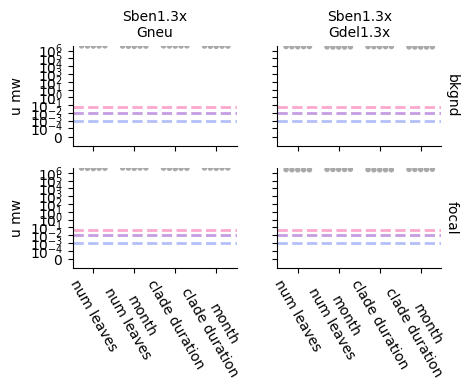

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


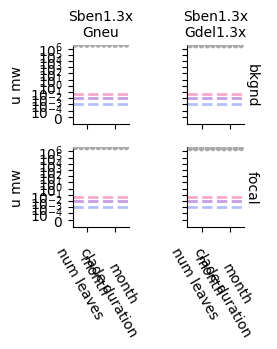

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


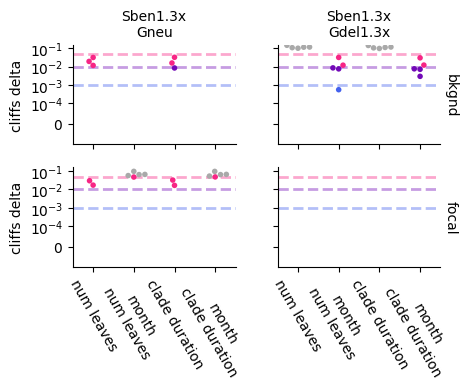

teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


teeplots/2025-05-19-compscreen-vanilla-big-1.3x-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


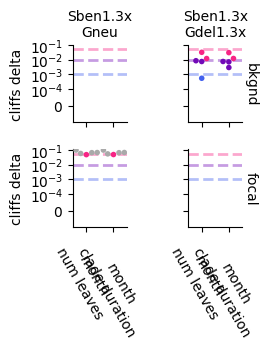

In [12]:
bins = [-np.inf, 0.001, 0.01, 0.05, np.inf]
labels = ["<0.001", "<0.01", "<0.05", "ns"]
gentle_palette = ["#4361EE", "#7209B7", "#F72585", "#A9A9A9"]

for y in "p_boot", "p_binom", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=2,
        aspect=1.2,
        palette=gentle_palette,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    with tp.teed(
        sns.catplot,
        data=data[data["y"].str.startswith("month").values],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        margin_titles=True,
        height=1.8,
        aspect=0.8,
        palette=gentle_palette,
        size=4,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(
                0.05,
                alpha=0.4,
                color=gentle_palette[2],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.01,
                alpha=0.4,
                color=gentle_palette[1],
                linestyle="--",
                linewidth=2,
            )
            ax.axhline(
                0.001,
                alpha=0.4,
                color=gentle_palette[0],
                linestyle="--",
                linewidth=2,
            )
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()
